# Predict


In [2]:
import gcsfs
import geopandas as gpd
import geoutils as gu
import joblib
import numpy as np
import rasterio as rio
import pandas as pd

import xdem

import subkart

In [ ]:
RESOLUTION = 25

# Predict for Norge

## Sjøkart data

In [ ]:
gdf_sea_map = subkart.sources.sea_map_basisdata(subkart.sources.FYLKER)
gdf_sea_map = subkart.features.depth_preprocess(gdf_sea_map)
transform, out_shape, bounds = subkart.features.to_raster_shapes(gdf_sea_map, res=RESOLUTION)
crs = gdf_sea_map.crs

## Marine Vanntyper

In [ ]:
marine_vanntyper = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/mdir/NyTypologi2022.geo.parquet").to_crs(gdf_sea_map.crs)
marine_vanntyper = subkart.features.marine_vanntyper_preprocess(marine_vanntyper)
minx, miny, maxx, maxy = gdf_sea_map.total_bounds
marine_vanntyper = marine_vanntyper.cx[minx:maxx, miny:maxy]


## DEM 50

In [ ]:
dem = xdem.DEM(rio.open("https://storage.googleapis.com/niva-geodata/MarintNaturKart/dem50_norge.tif"))
dem = subkart.utils.resample_dem(dem, out_shape, transform, crs)

# Predict for AOI

In [ ]:
gdf_sea_map_more = gpd.read_parquet(
    "gs://niva-geodata/MarintNaturKart/Basisdata_15_More_og_Romsdal_25833_Dybdedata_Dybdeareal.geo.parquet"
)
gdf_sea_map_more = subkart.features.depth_preprocess(gdf_sea_map_more)
crs = gdf_sea_map_more.crs

In [ ]:
gdf_bunn_moere = gpd.read_file(
    "https://storage.googleapis.com/niva-geodata/MarintNaturKart/bunn_in_kommuner_sea.geojson"
)
gdf_clip = gdf_bunn_moere.to_crs(gdf_sea_map_more.crs)

vec_clip = gu.Vector(gdf_clip)

In [12]:
clipped_marine_vanntyper = gdf_clip.overlay(marine_vanntyper)

In [ ]:
clipped_gdf = gdf_clip.overlay(gdf_sea_map_more)

In [26]:
transform, out_shape, bounds = subkart.features.to_raster_shapes(clipped_gdf, res=RESOLUTION)
dem = xdem.DEM(rio.open("https://storage.googleapis.com/niva-geodata/MarintNaturKart/dem50_vestland.tif"))
dem = subkart.utils.resample_dem(dem, out_shape, transform, crs)

In [ ]:
X, valid_attrs, out_shape, transform = subkart.features.build(
    dem, clipped_gdf, clipped_marine_vanntyper, valid_mask=None, res=RESOLUTION, dtype=np.float16
)

Processing avg_depth...


/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Processing avg_slope...


/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Processing compactness...


/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Processing convexity...


/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Processing marine types...
Stacking feature arrays...


In [39]:
fs = gcsfs.GCSFileSystem()
with fs.open("gs://niva-geodata/MarintNaturKart/classifier.joblib", "rb") as f:
    classifier = joblib.load(f)

In [31]:
Y_pred = classifier.predict(X)

In [32]:
pred_map = np.full(out_shape, np.nan, dtype=np.float32)
pred_map[valid_attrs] = Y_pred.astype(np.float32)

In [33]:
pred_raster = gu.Raster.from_array(pred_map, transform=transform, crs=crs)

/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


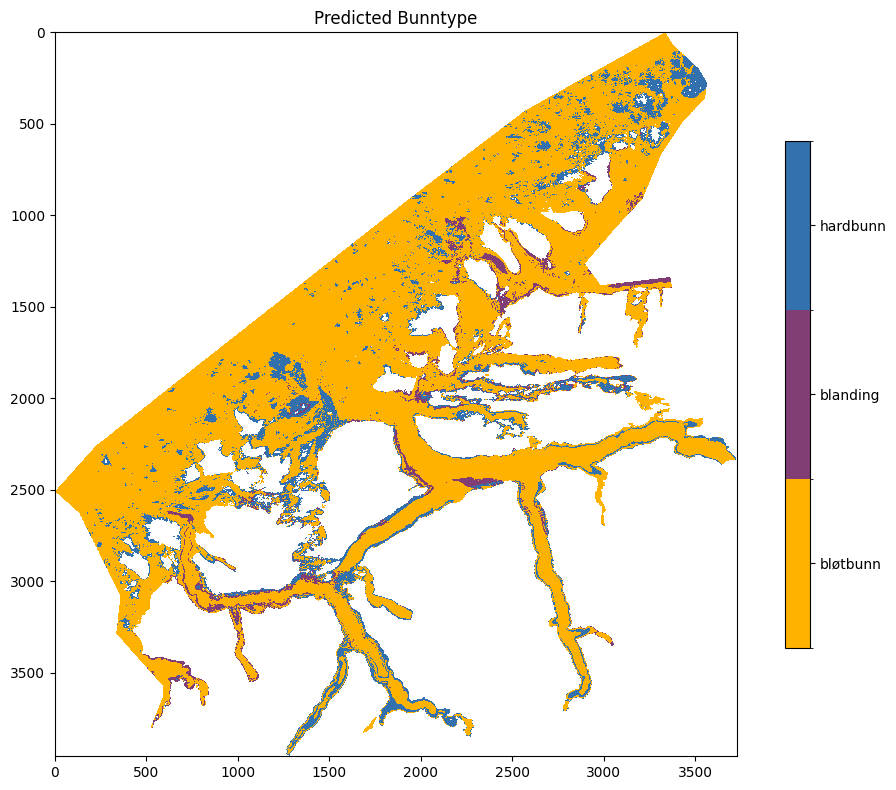

In [34]:
subkart.utils.plot_prediction_raster(pred_raster)

# Vectorize output

In [35]:
pred_vec = pred_raster.polygonize()

/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/interface/raster_vector.py:102: RuntimeWarning: invalid value encountered in cast
  shapes(source_raster.data.astype(final_dtype), mask=bool_msk, transform=source_raster.transform)


In [36]:
# Map raster_value (0/1) to BunnType using existing mapping_values
reverse_map = {v: k for k, v in subkart.labelling.BUNNTYPE_MAPPING.items()}
pred_vec["BunnType"] = pred_vec["raster_value"].map(reverse_map)

pred_vec["BunnType"]

0        fastbunn
1        fastbunn
2        fastbunn
3        fastbunn
4         løsbunn
           ...   
32097    fastbunn
32098    fastbunn
32099     løsbunn
32100     løsbunn
32101    fastbunn
Name: BunnType, Length: 32102, dtype: object

In [37]:
gdf_final = pred_vec.ds.to_crs("EPSG:25833")

In [38]:
fname = subkart.utils.to_filename(
    f"nisjedata-substrat-{classifier.__class__.__name__.lower()}", "moere-og-romsdal", "latest", gdf_final.crs.to_epsg()
)
gdf_final = gdf_final.drop(columns=["depth_range", "class"], errors="ignore")
gdf_final.to_file(f"{fname}.geojson", driver="GeoJSON")